# IEEE-CIS Fraud Detection - XGBoost Experiment


## Setup


In [1]:
import os
import warnings
import pickle
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

import mlflow
import mlflow.sklearn
import dagshub

print('All imports successful')

All imports successful


In [2]:
dagshub.init(
    repo_owner='sansi23',
    repo_name='IEEE-CIS-Fraud-Detection',
    mlflow=True
)

mlflow.set_experiment('XGBoost_Training')

Accessing as sansi23

Initialized MLflow to track repo "sansi23/IEEE-CIS-Fraud-Detection"

Repository sansi23/IEEE-CIS-Fraud-Detection initialized!

<Experiment: artifact_location='mlflow-artifacts:/c2cbe562a36b4c1c957fff3a7221d284', creation_time=1777711936042, experiment_id='2', last_update_time=1777711936042, lifecycle_stage='active', name='XGBoost_Training', tags={'mlflow.experimentKind': 'custom_model_development'}, workspace='default'>

In [68]:
import os
import warnings
import pickle
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
import mlflow
import mlflow.sklearn
import dagshub

class FullPreprocessor(BaseEstimator, TransformerMixin):
    LOW_CARD_COLS  = ['ProductCD', 'card4', 'card6', 'DeviceType',
                      'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
    HIGH_CARD_COLS = ['P_emaildomain', 'R_emaildomain', 'DeviceInfo']

    def __init__(self, missing_thresh=0.9):
        self.missing_thresh = missing_thresh

    def fit(self, X, y=None):
        X = X.copy()

        self.high_missing_ = X.columns[X.isnull().mean() > self.missing_thresh].tolist()
        X.drop(columns=self.high_missing_, inplace=True)

        self.fill_values_ = {}
        for col in X.columns:
            if X[col].isnull().any():
                if X[col].dtype == 'object':
                    mode_vals = X[col].mode(dropna=True)
                    self.fill_values_[col] = mode_vals.iloc[0] if len(mode_vals) else 'Unknown'
                else:
                    self.fill_values_[col] = X[col].median()
        for col, val in self.fill_values_.items():
            X[col].fillna(val, inplace=True)

        X = self._add_features(X, is_fit=True)

        self.woe_maps_ = {}
        if y is not None:
            y_aligned = y.values
            total_ev  = y_aligned.sum()
            total_nev = (1 - y_aligned).sum()
            for col in self.HIGH_CARD_COLS:
                if col in X.columns:
                    col_vals = X[col].astype(str).values
                    woe_map  = {}
                    for cat in np.unique(col_vals):
                        mask       = col_vals == cat
                        events     = y_aligned[mask].sum()
                        non_events = (1 - y_aligned[mask]).sum()
                        dist_ev    = (events     + 0.5) / (total_ev  + 0.5)
                        dist_nev   = (non_events + 0.5) / (total_nev + 0.5)
                        woe_map[cat] = np.log(dist_ev / dist_nev)
                    self.woe_maps_[col] = woe_map

        for uid in ['uid1', 'uid2', 'uid3']:
            if uid in X.columns:
                X.drop(columns=[uid], inplace=True)

        ohe_present = [c for c in self.LOW_CARD_COLS if c in X.columns]
        X = pd.get_dummies(X, columns=ohe_present, drop_first=True, dtype=bool)

        for col, woe_map in self.woe_maps_.items():
            if col in X.columns:
                X[col] = X[col].astype(str).map(woe_map).fillna(0)

        remaining = X.select_dtypes(include='object').columns.tolist()
        if remaining:
            X = pd.get_dummies(X, columns=remaining, drop_first=True, dtype=bool)

        self.fitted_columns_ = X.columns.tolist()
        return self

    def transform(self, X):
        X = X.copy()

        X.drop(columns=[c for c in self.high_missing_ if c in X.columns], inplace=True)

        for col, val in self.fill_values_.items():
            if col in X.columns:
                X[col].fillna(val, inplace=True)

        X = self._add_features(X, is_fit=False)

        for uid in ['uid1', 'uid2', 'uid3']:
            if uid in X.columns:
                X.drop(columns=[uid], inplace=True)

        ohe_present = [c for c in self.LOW_CARD_COLS if c in X.columns]
        X = pd.get_dummies(X, columns=ohe_present, drop_first=True, dtype=bool)

        for col, woe_map in self.woe_maps_.items():
            if col in X.columns:
                X[col] = X[col].astype(str).map(woe_map).fillna(0)

        remaining = X.select_dtypes(include='object').columns.tolist()
        if remaining:
            X = pd.get_dummies(X, columns=remaining, drop_first=True, dtype=bool)

        X = X.reindex(columns=self.fitted_columns_, fill_value=0)
        return X

    def _add_features(self, df, is_fit=False):
        if 'TransactionAmt' in df.columns:
            df['TransactionAmt_log1p'] = np.log1p(df['TransactionAmt'])
            df['TransactionAmt_cents'] = (df['TransactionAmt'] % 1).round(2)

        if 'TransactionDT' in df.columns:
            df['TransactionDT_day']  = (df['TransactionDT'] // 86400).astype('float32')
            df['TransactionDT_hour'] = ((df['TransactionDT'] // 3600) % 24).astype('float32')

        for col in ['P_emaildomain', 'R_emaildomain']:
            if col in df.columns:
                df[f'{col}_provider'] = df[col].astype(str).str.split('.').str[0]

        if is_fit:
            self.card_agg_ = {}
            for col in ['card1', 'card2', 'card3', 'card5']:
                if col in df.columns and 'TransactionAmt' in df.columns:
                    self.card_agg_[col] = {
                        'mean': df.groupby(col)['TransactionAmt'].mean(),
                        'std':  df.groupby(col)['TransactionAmt'].std().fillna(0)
                    }

            self.freq_maps_ = {}
            for col in ['card1', 'card2', 'P_emaildomain', 'DeviceInfo']:
                if col in df.columns:
                    self.freq_maps_[col] = df[col].value_counts()

            self.card1_stats_ = {}
            if 'card1' in df.columns and 'TransactionAmt' in df.columns:
                self.card1_stats_['count']   = df.groupby('card1')['TransactionAmt'].count()
                self.card1_stats_['nunique'] = df.groupby('card1')['TransactionAmt'].nunique()

            self.card1_unique_items_ = {}
            if 'card1' in df.columns and 'ProductCD' in df.columns:
                combo = (df['card1'].astype(str) + '_' +
                        df['ProductCD'].astype(str) + '_' +
                        df['TransactionAmt'].astype(str))
                self.card1_unique_items_ = combo.groupby(df['card1']).nunique()
            
            if 'card1' in df.columns and 'addr1' in df.columns:
                df['uid1'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str)
            if 'card1' in df.columns and 'addr1' in df.columns and 'P_emaildomain' in df.columns:
                df['uid2'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str) + '_' + df['P_emaildomain'].astype(str)
            if 'card1' in df.columns and 'card5' in df.columns:
                df['uid3'] = df['card1'].astype(str) + '_' + df['card5'].astype(str)

            self.uid_agg_ = {}
            for uid in ['uid1', 'uid2', 'uid3']:
                if uid in df.columns and 'TransactionAmt' in df.columns:
                    self.uid_agg_[uid] = {
                        'mean':  df.groupby(uid)['TransactionAmt'].mean(),
                        'std':   df.groupby(uid)['TransactionAmt'].std().fillna(0),
                        'count': df.groupby(uid)['TransactionAmt'].count(),
                        'freq':  df[uid].value_counts()
                    }

        if 'card1' in df.columns and 'addr1' in df.columns:
            df['uid1'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str)
        if 'card1' in df.columns and 'addr1' in df.columns and 'P_emaildomain' in df.columns:
            df['uid2'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str) + '_' + df['P_emaildomain'].astype(str)
        if 'card1' in df.columns and 'card5' in df.columns:
            df['uid3'] = df['card1'].astype(str) + '_' + df['card5'].astype(str)

        for uid, aggs in self.uid_agg_.items():
            if uid in df.columns:
                df[f'{uid}_amt_mean']  = df[uid].map(aggs['mean']).fillna(aggs['mean'].mean())
                df[f'{uid}_amt_std']   = df[uid].map(aggs['std']).fillna(aggs['std'].mean())
                df[f'{uid}_txn_count'] = df[uid].map(aggs['count']).fillna(0)
                df[f'{uid}_freq']      = df[uid].map(aggs['freq']).fillna(0)

        for col, aggs in self.card_agg_.items():
            df[f'{col}_amt_mean'] = df[col].map(aggs['mean']).fillna(aggs['mean'].mean())
            df[f'{col}_amt_std']  = df[col].map(aggs['std']).fillna(aggs['std'].mean())

        if 'P_emaildomain' in df.columns:
            df['P_email_high_fraud'] = df['P_emaildomain'].isin(['protonmail.com', 'mail.com']).astype(int)

        if 'TransactionDT_hour' in df.columns:
            df['is_night'] = (df['TransactionDT_hour'].between(0, 5)).astype(int)

        if 'card1_amt_mean' in df.columns:
            df['card1_amt_deviation'] = df['TransactionAmt'] / (df['card1_amt_mean'] + 1)
            df['card1_amt_zscore']    = (df['TransactionAmt'] - df['card1_amt_mean']) / (df['card1_amt_std'] + 1)

        for col, freq_map in self.freq_maps_.items():
            if col in df.columns:
                df[f'{col}_freq'] = df[col].map(freq_map).fillna(0)

        if self.card1_stats_:
            df['card1_txn_count']      = df['card1'].map(self.card1_stats_['count']).fillna(0)
            df['card1_unique_amounts'] = df['card1'].map(self.card1_stats_['nunique']).fillna(0)

        if 'card1' in df.columns and 'TransactionDT' in df.columns:
            original_index = df.index
            df = df.sort_values('TransactionDT')
            df['card1_prev_dt']  = df.groupby('card1')['TransactionDT'].shift(1)
            df['card1_time_gap'] = (df['TransactionDT'] - df['card1_prev_dt']).fillna(-1)
            df = df.drop(columns=['card1_prev_dt'])
            df = df.loc[original_index]

        if hasattr(self, 'card1_unique_items_') and 'card1' in df.columns:
            df['card1_unique_items'] = df['card1'].map(self.card1_unique_items_).fillna(0)

        return df


class CorrelationDropper(BaseEstimator, TransformerMixin):
    ENGINEERED_COLS = [
    'TransactionAmt_log1p', 'TransactionAmt_cents', 'TransactionDT_day',
    'TransactionDT_hour', 'P_emaildomain_provider', 'R_emaildomain_provider',
    'card1_amt_mean', 'card1_amt_std', 'card2_amt_mean', 'card2_amt_std',
    'card3_amt_mean', 'card3_amt_std', 'card5_amt_mean', 'card5_amt_std',
    'P_email_high_fraud', 'is_night', 'card1_amt_deviation', 'card1_amt_zscore',
    'card1_freq', 'card2_freq', 'P_emaildomain_freq', 'DeviceInfo_freq',
    'card1_unique_amounts', 'card1_txn_count', 'card1_time_gap', 'card1_unique_items',
    'uid1', 'uid2', 'uid3',
    'uid1_amt_mean', 'uid1_amt_std', 'uid1_txn_count', 'uid1_freq',
    'uid2_amt_mean', 'uid2_amt_std', 'uid2_txn_count', 'uid2_freq',
    'uid3_amt_mean', 'uid3_amt_std', 'uid3_txn_count', 'uid3_freq',
]

    def __init__(self, threshold=0.9):
        self.threshold = threshold

    def fit(self, X, y=None):
        self.feature_names_ = X.columns.tolist()

        cols_to_check = [c for c in X.columns if c not in self.ENGINEERED_COLS]
    
        X_sample = X[cols_to_check].sample(n=min(50000, len(X)), random_state=42)
        corr_matrix = X_sample.corr().abs()
    
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        self.to_drop_ = [c for c in upper.columns if any(upper[c] > self.threshold)]
        self.kept_features_ = [f for f in self.feature_names_ if f not in self.to_drop_]
        print(f'CorrelationDropper: dropped {len(self.to_drop_)}/{len(self.feature_names_)}')
        return self

    def transform(self, X):
        return X[[c for c in self.kept_features_ if c in X.columns]]


class IVFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.02):
        self.threshold = threshold

    def fit(self, X, y):
        iv_scores = {}
        y_vals    = np.asarray(y)  
        total_ev  = y_vals.sum()
        total_nev = (1 - y_vals).sum()
        for col in X.columns:
            col_vals = X[col].to_numpy()  
            if X[col].nunique() > 10:
                try:
                    bins = pd.qcut(X[col], q=10, duplicates='drop').to_numpy()  #
                except Exception:
                    bins = col_vals  
            else:
                bins = col_vals  
            iv = 0
            for val in np.unique(bins):  
                mask       = bins == val  
                events     = y_vals[mask].sum()  
                non_events = (1 - y_vals[mask]).sum()  
                dist_ev    = (events + 0.5) / (total_ev  + 0.5)
                dist_nev   = (non_events + 0.5) / (total_nev + 0.5)
                iv         += (dist_ev - dist_nev) * np.log(dist_ev / dist_nev)
            iv_scores[col] = iv
        iv_series = pd.Series(iv_scores)
        self.keep_    = iv_series[iv_series >= self.threshold].index.tolist()
        self.dropped_ = iv_series[iv_series <  self.threshold].index.tolist()
        print(f'IVFeatureSelector: kept {len(self.keep_)}/{len(iv_scores)}')
        return self

    def transform(self, X):
        return X[[c for c in self.keep_ if c in X.columns]]


class XGBFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold='mean', random_state=42):
        self.threshold    = threshold
        self.random_state = random_state

    def fit(self, X, y):
        self.feature_names_ = X.columns.tolist()
        model = XGBClassifier(
            random_state=self.random_state,
            eval_metric='auc',
            verbosity=0,
            tree_method='hist'
        )
        model.fit(X, y)
        importances  = model.feature_importances_
        thresh_value = importances.mean() if self.threshold == 'mean' else float(self.threshold)
        self.feature_mask_      = importances >= thresh_value
        self.selected_features_ = np.array(self.feature_names_)[self.feature_mask_]
        print(f'XGBFeatureSelector: kept {self.feature_mask_.sum()}/{len(importances)}')
        return self

    def transform(self, X):
        return X[[c for c in self.selected_features_ if c in X.columns]]


print('Done.')

Done.


## Data Loading


In [4]:
train_transaction = pd.read_csv('train_transaction.csv')
train_identity    = pd.read_csv('train_identity.csv')
test_transaction  = pd.read_csv('test_transaction.csv')
test_identity     = pd.read_csv('test_identity.csv')

train = train_transaction.merge(train_identity, on='TransactionID', how='left')
test  = test_transaction.merge(test_identity,  on='TransactionID', how='left')

print('Train shape:', train.shape)
print('Test shape: ', test.shape)
train.head()

Train shape: (590540, 434)
Test shape:  (506691, 433)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


Fraud rate: 3.4990%


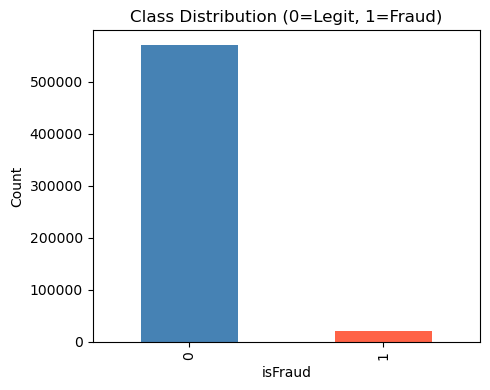

In [8]:
TARGET = 'isFraud'
ID_COL = 'TransactionID'

fraud_rate = train[TARGET].mean()
print(f'Fraud rate: {fraud_rate:.4%}')

fig, ax = plt.subplots(figsize=(5, 4))
train[TARGET].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('Class Distribution (0=Legit, 1=Fraud)')
ax.set_xlabel('isFraud')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [9]:
test_ids = test[ID_COL].copy()

X = train.drop(columns=[TARGET, ID_COL])
y = train[TARGET].astype(int)
X_test_raw = test.drop(columns=[ID_COL])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape}')
print(f'Val size:   {X_val.shape}')

Train size: (472432, 432)
Val size:   (118108, 432)


## Exploratory Data Analysis

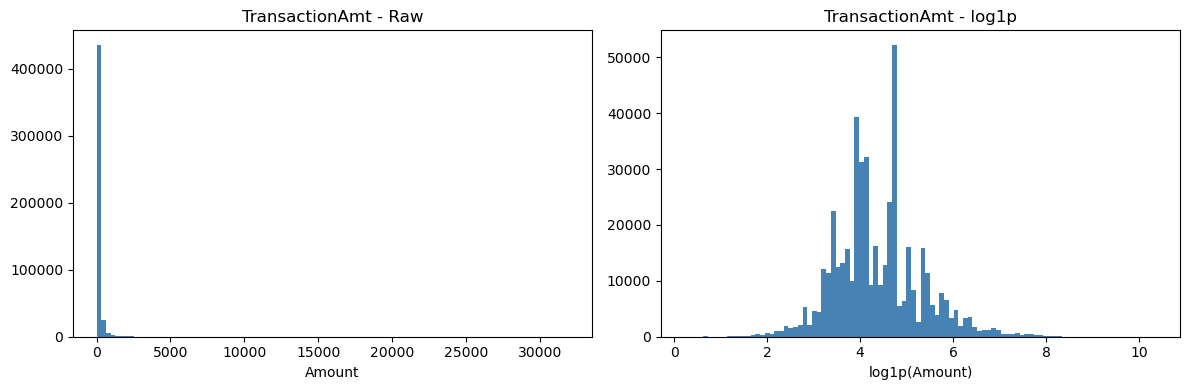

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X_train['TransactionAmt'], bins=100, color='steelblue')
axes[0].set_title('TransactionAmt - Raw')
axes[0].set_xlabel('Amount')
axes[1].hist(np.log1p(X_train['TransactionAmt']), bins=100, color='steelblue')
axes[1].set_title('TransactionAmt - log1p')
axes[1].set_xlabel('log1p(Amount)')
plt.tight_layout()
plt.show()

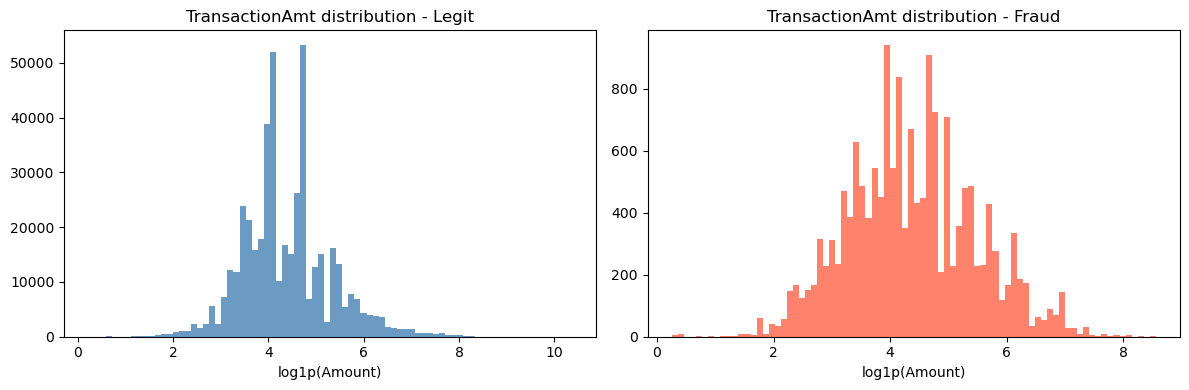

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, label, color in zip(axes, [0, 1], ['steelblue', 'tomato']):
    vals = X_train.loc[y_train == label, 'TransactionAmt']
    ax.hist(np.log1p(vals), bins=80, color=color, alpha=0.8)
    ax.set_title(f'TransactionAmt distribution - {"Legit" if label == 0 else "Fraud"}')
    ax.set_xlabel('log1p(Amount)')
plt.tight_layout()
plt.show()

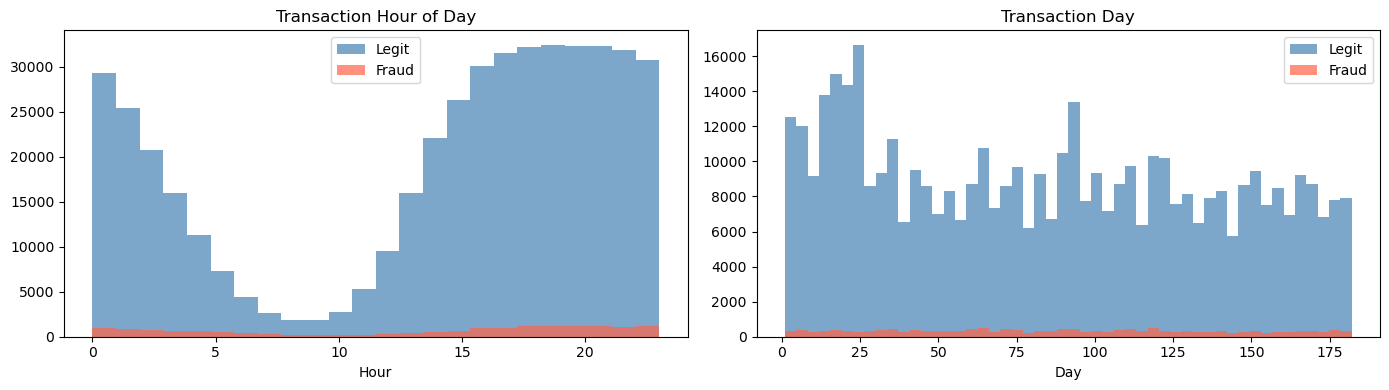

In [12]:
hours = ((X_train['TransactionDT'] // 3600) % 24).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(hours[y_train == 0], bins=24, color='steelblue', alpha=0.7, label='Legit')
axes[0].hist(hours[y_train == 1], bins=24, color='tomato',    alpha=0.7, label='Fraud')
axes[0].set_title('Transaction Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].legend()

days = (X_train['TransactionDT'] // 86400).astype(int)
axes[1].hist(days[y_train == 0], bins=50, color='steelblue', alpha=0.7, label='Legit')
axes[1].hist(days[y_train == 1], bins=50, color='tomato',    alpha=0.7, label='Fraud')
axes[1].set_title('Transaction Day')
axes[1].set_xlabel('Day')
axes[1].legend()

plt.tight_layout()
plt.show()

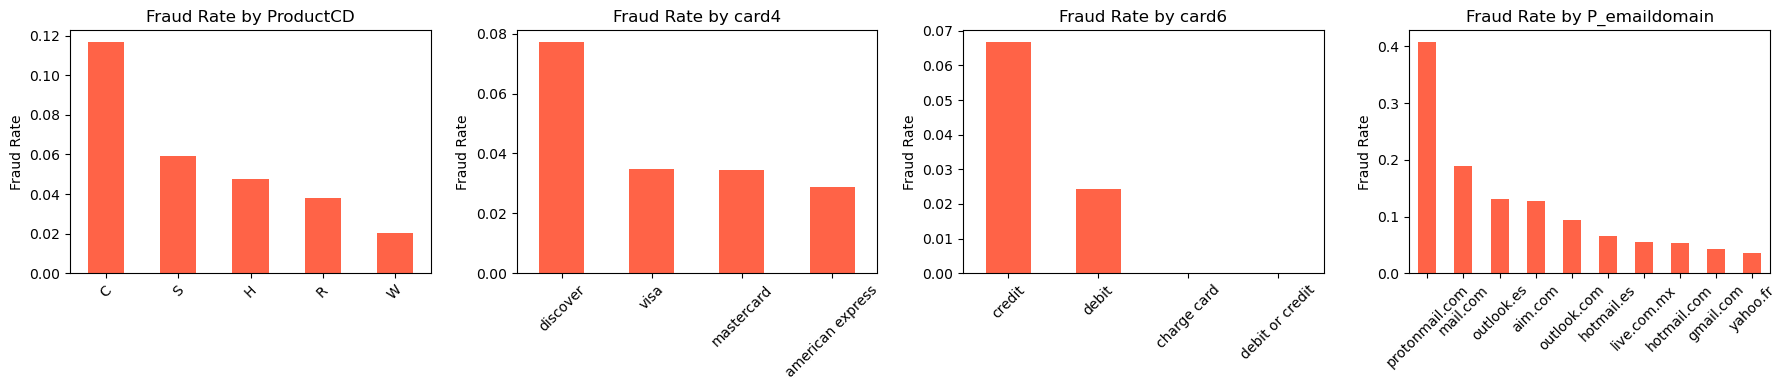

In [13]:
top_cats = ['ProductCD', 'card4', 'card6', 'P_emaildomain']
fig, axes = plt.subplots(1, len(top_cats), figsize=(18, 4))

for ax, col in zip(axes, top_cats):
    fraud_rate_by_cat = train.groupby(col)[TARGET].mean().sort_values(ascending=False).head(10)
    fraud_rate_by_cat.plot(kind='bar', ax=ax, color='tomato')
    ax.set_title(f'Fraud Rate by {col}')
    ax.set_ylabel('Fraud Rate')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Data Cleaning


### Missing Value Analysis


       Missing Count  Missing %
id_24         468639      99.20
id_25         468330      99.13
id_07         468318      99.13
id_08         468318      99.13
id_21         468313      99.13
id_26         468310      99.13
id_27         468306      99.13
id_23         468306      99.13
id_22         468306      99.13
dist2         442276      93.62
D7            441253      93.40
id_18         436308      92.35
D13           422692      89.47
D14           422488      89.43
D12           420479      89.00
id_03         419240      88.74
id_04         419240      88.74
D6            413676      87.56
id_33         413642      87.56
id_10         412303      87.27
id_09         412303      87.27
D8            412303      87.27
D9            412303      87.27
id_30         410249      86.84
id_32         410229      86.83
id_34         410062      86.80
id_14         408264      86.42
V155          406761      86.10
V138          406761      86.10
V156          406761      86.10


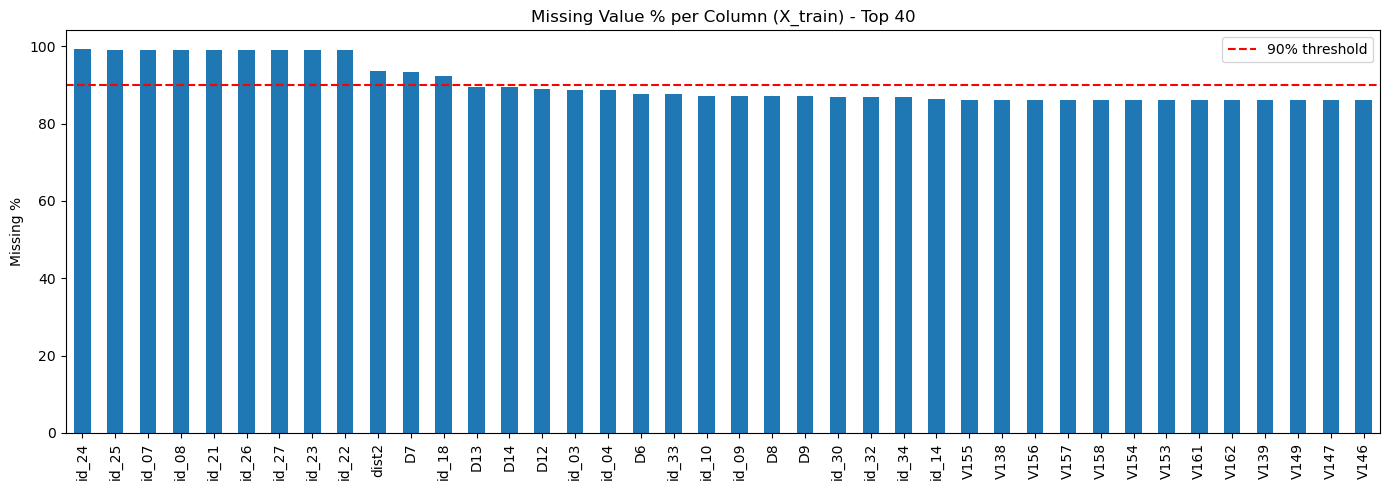

In [14]:
missing = X_train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(X_train) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df.head(30))

plt.figure(figsize=(14, 5))
missing_pct.head(40).plot(kind='bar')
plt.title('Missing Value % per Column (X_train) - Top 40')
plt.ylabel('Missing %')
plt.axhline(y=90, color='red', linestyle='--', label='90% threshold')
plt.legend()
plt.tight_layout()
plt.show()

### Drop High-Missing Columns (>90%)


In [15]:
with mlflow.start_run(run_name='XGBoost_Cleaning'):
    missing_pct_local = (X_train.isnull().mean() * 100)
    high_missing = missing_pct_local[missing_pct_local > 90].index.tolist()
    print(f'Dropping {len(high_missing)} columns with >90% missing: {high_missing}')

    X_train_c = X_train.drop(columns=high_missing)
    X_val_c   = X_val.drop(columns=[c for c in high_missing if c in X_val.columns])
    X_test_c  = X_test_raw.drop(columns=[c for c in high_missing if c in X_test_raw.columns])

    remaining_missing = X_train_c.isnull().sum().sum()

    mlflow.log_metric('original_feature_count',    X_train.shape[1])
    mlflow.log_metric('dropped_high_missing_cols', len(high_missing))
    mlflow.log_metric('remaining_feature_count',   X_train_c.shape[1])
    mlflow.log_metric('remaining_missing_values',  int(remaining_missing))

    print(f'Features after drop: {X_train_c.shape[1]}')
    print(f'Remaining na cells: {remaining_missing}')

Dropping 12 columns with >90% missing: ['dist2', 'D7', 'id_07', 'id_08', 'id_18', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27']
Features after drop: 420
Remaining na cells: 86849187
🏃 View run XGBoost_Cleaning at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2/runs/a5b858efaa384e95b7cafad4c5895a20
🧪 View experiment at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2


### Imputation


In [16]:
def impute(df_train, df_val, df_test):
    df_train, df_val, df_test = df_train.copy(), df_val.copy(), df_test.copy()

    common_cols = sorted(set(df_train.columns) & set(df_val.columns) & set(df_test.columns))
    df_train = df_train[common_cols]
    df_val   = df_val[common_cols]
    df_test  = df_test[common_cols]

    for col in common_cols:
        if df_train[col].isnull().any() or df_val[col].isnull().any() or df_test[col].isnull().any():
            if df_train[col].dtype == 'object':
                mode_vals = df_train[col].mode(dropna=True)
                fill_val  = mode_vals.iloc[0] if len(mode_vals) else 'Unknown'
            else:
                fill_val = df_train[col].median()

            df_train[col] = df_train[col].fillna(fill_val)
            df_val[col]   = df_val[col].fillna(fill_val)
            df_test[col]  = df_test[col].fillna(fill_val)

    return df_train, df_val, df_test

X_train_c, X_val_c, X_test_c = impute(X_train_c, X_val_c, X_test_c)

print('Nulls in X_train:', X_train_c.isnull().sum().sum())
print('Nulls in X_val:',   X_val_c.isnull().sum().sum())
print('Nulls in X_test:',  X_test_c.isnull().sum().sum())
print('Aligned feature count:', X_train_c.shape[1])

Nulls in X_train: 0
Nulls in X_val: 0
Nulls in X_test: 0
Aligned feature count: 392


## Feature Engineering


In [59]:
def add_features(df, ref=None):
    df  = df.copy()
    ref = ref if ref is not None else df

    if 'TransactionAmt' in df.columns:
        df['TransactionAmt_log1p'] = np.log1p(df['TransactionAmt'])
        df['TransactionAmt_cents'] = (df['TransactionAmt'] % 1).round(2)

    if 'TransactionDT' in df.columns:
        df['TransactionDT_day']  = (df['TransactionDT'] // 86400).astype('float32')
        df['TransactionDT_hour'] = ((df['TransactionDT'] // 3600) % 24).astype('float32')

    for col in ['P_emaildomain', 'R_emaildomain']:
        if col in df.columns:
            df[f'{col}_provider'] = df[col].astype(str).str.split('.').str[0]

    for col in ['card1', 'card2', 'card3', 'card5']:
        if col in ref.columns and 'TransactionAmt' in ref.columns:
            grp_mean = ref.groupby(col)['TransactionAmt'].mean()
            grp_std  = ref.groupby(col)['TransactionAmt'].std().fillna(0)
            df[f'{col}_amt_mean'] = df[col].map(grp_mean).fillna(grp_mean.mean())
            df[f'{col}_amt_std']  = df[col].map(grp_std).fillna(grp_std.mean())

    if 'P_emaildomain' in df.columns:
        df['P_email_high_fraud'] = df['P_emaildomain'].isin(['protonmail.com', 'mail.com']).astype(int)

    if 'TransactionDT_hour' in df.columns:
        df['is_night'] = (df['TransactionDT_hour'].between(0, 5)).astype(int)

    if 'card1_amt_mean' in df.columns:
        df['card1_amt_deviation'] = df['TransactionAmt'] / (df['card1_amt_mean'] + 1)
        df['card1_amt_zscore']    = (df['TransactionAmt'] - df['card1_amt_mean']) / (df['card1_amt_std'] + 1)

    for col in ['card1', 'card2', 'P_emaildomain', 'DeviceInfo']:
        if col in ref.columns:
            freq_map = ref[col].value_counts()
            df[f'{col}_freq'] = df[col].map(freq_map).fillna(0)

    if 'card1' in ref.columns and 'TransactionAmt' in ref.columns:
        df['card1_txn_count']      = df['card1'].map(ref.groupby('card1')['TransactionAmt'].count()).fillna(0)
        df['card1_unique_amounts'] = df['card1'].map(ref.groupby('card1')['TransactionAmt'].nunique()).fillna(0)

    if 'card1' in df.columns and 'TransactionDT' in df.columns:
        original_index = df.index
        df = df.sort_values('TransactionDT')
        df['card1_prev_dt']  = df.groupby('card1')['TransactionDT'].shift(1)
        df['card1_time_gap'] = (df['TransactionDT'] - df['card1_prev_dt']).fillna(-1)
        df = df.drop(columns=['card1_prev_dt'])
        df = df.loc[original_index]

    if 'card1' in ref.columns and 'ProductCD' in ref.columns:
        combo = (ref['card1'].astype(str) + '_' +
                 ref['ProductCD'].astype(str) + '_' +
                 ref['TransactionAmt'].astype(str))
        card1_unique_items = combo.groupby(ref['card1']).nunique()
        df['card1_unique_items'] = df['card1'].map(card1_unique_items).fillna(0)

    if 'card1' in df.columns and 'addr1' in df.columns:
        df['uid1'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str)
    if 'card1' in df.columns and 'addr1' in df.columns and 'P_emaildomain' in df.columns:
        df['uid2'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str) + '_' + df['P_emaildomain'].astype(str)
    if 'card1' in df.columns and 'card5' in df.columns:
        df['uid3'] = df['card1'].astype(str) + '_' + df['card5'].astype(str)

    ref_uid = ref.copy() if ref is not df else df
    if 'uid1' not in ref_uid.columns and 'card1' in ref_uid.columns and 'addr1' in ref_uid.columns:
        ref_uid['uid1'] = ref_uid['card1'].astype(str) + '_' + ref_uid['addr1'].astype(str)
    if 'uid2' not in ref_uid.columns and 'card1' in ref_uid.columns and 'addr1' in ref_uid.columns and 'P_emaildomain' in ref_uid.columns:
        ref_uid['uid2'] = ref_uid['card1'].astype(str) + '_' + ref_uid['addr1'].astype(str) + '_' + ref_uid['P_emaildomain'].astype(str)
    if 'uid3' not in ref_uid.columns and 'card1' in ref_uid.columns and 'card5' in ref_uid.columns:
        ref_uid['uid3'] = ref_uid['card1'].astype(str) + '_' + ref_uid['card5'].astype(str)

    for uid in ['uid1', 'uid2', 'uid3']:
        if uid in ref_uid.columns and uid in df.columns and 'TransactionAmt' in ref_uid.columns:
            uid_mean  = ref_uid.groupby(uid)['TransactionAmt'].mean()
            uid_std   = ref_uid.groupby(uid)['TransactionAmt'].std().fillna(0)
            uid_count = ref_uid.groupby(uid)['TransactionAmt'].count()
            uid_freq  = ref_uid[uid].value_counts()
            df[f'{uid}_amt_mean']  = df[uid].map(uid_mean).fillna(uid_mean.mean())
            df[f'{uid}_amt_std']   = df[uid].map(uid_std).fillna(uid_std.mean())
            df[f'{uid}_txn_count'] = df[uid].map(uid_count).fillna(0)
            df[f'{uid}_freq']      = df[uid].map(uid_freq).fillna(0)

    return df

with mlflow.start_run(run_name='XGBoost_Feature_Engineering'):
    X_train_fe = add_features(X_train_c).reset_index(drop=True)

    X_train_c_with_uid = X_train_c.copy()
    X_train_c_with_uid['uid1'] = X_train_fe['uid1'].values
    X_train_c_with_uid['uid2'] = X_train_fe['uid2'].values
    X_train_c_with_uid['uid3'] = X_train_fe['uid3'].values

    X_val_fe   = add_features(X_val_c,  ref=X_train_c_with_uid).reset_index(drop=True)
    X_test_fe  = add_features(X_test_c, ref=X_train_c_with_uid).reset_index(drop=True)

    y_train = y_train.reset_index(drop=True)
    y_val   = y_val.reset_index(drop=True)

    new_cols = [c for c in X_train_fe.columns if c not in X_train_c.columns]
    mlflow.log_metric('engineered_feature_count', len(new_cols))
    print(f'New features added ({len(new_cols)}): {new_cols}')
    print('X_train_fe shape:', X_train_fe.shape)

New features added (41): ['TransactionAmt_log1p', 'TransactionAmt_cents', 'TransactionDT_day', 'TransactionDT_hour', 'P_emaildomain_provider', 'R_emaildomain_provider', 'card1_amt_mean', 'card1_amt_std', 'card2_amt_mean', 'card2_amt_std', 'card3_amt_mean', 'card3_amt_std', 'card5_amt_mean', 'card5_amt_std', 'P_email_high_fraud', 'is_night', 'card1_amt_deviation', 'card1_amt_zscore', 'card1_freq', 'card2_freq', 'P_emaildomain_freq', 'DeviceInfo_freq', 'card1_txn_count', 'card1_unique_amounts', 'card1_time_gap', 'card1_unique_items', 'uid1', 'uid2', 'uid3', 'uid1_amt_mean', 'uid1_amt_std', 'uid1_txn_count', 'uid1_freq', 'uid2_amt_mean', 'uid2_amt_std', 'uid2_txn_count', 'uid2_freq', 'uid3_amt_mean', 'uid3_amt_std', 'uid3_txn_count', 'uid3_freq']
X_train_fe shape: (472432, 433)
🏃 View run XGBoost_Feature_Engineering at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2/runs/e7f28ec402e84695a58b59aba9a3339a
🧪 View experiment at: https://dagshub.com/sansi23/IEEE-CI

## OHE + WOE Encoding


In [60]:
import numpy as np

X_train_fe2 = X_train_fe.copy().reset_index(drop=True)
X_val_fe2   = X_val_fe.copy().reset_index(drop=True)
X_test_fe2  = X_test_fe.copy().reset_index(drop=True)

uid_cols = ['uid1', 'uid2', 'uid3']
X_train_fe2 = X_train_fe2.drop(columns=[c for c in uid_cols if c in X_train_fe2.columns])
X_val_fe2   = X_val_fe2.drop(columns=[c for c in uid_cols if c in X_val_fe2.columns])
X_test_fe2  = X_test_fe2.drop(columns=[c for c in uid_cols if c in X_test_fe2.columns])


LOW_CARD_COLS  = ['ProductCD', 'card4', 'card6', 'DeviceType', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
HIGH_CARD_COLS = ['P_emaildomain', 'R_emaildomain', 'DeviceInfo']

def woe_encode(train_col, val_col, test_col, y_train):
    woe_map   = {}
    total_ev  = y_train.sum()
    total_nev = (1 - y_train).sum()
    for cat in train_col.astype(str).unique():
        mask       = train_col.astype(str) == cat
        events     = y_train[mask].sum()
        non_events = (1 - y_train[mask]).sum()
        dist_ev    = (events     + 0.5) / (total_ev  + 0.5)
        dist_nev   = (non_events + 0.5) / (total_nev + 0.5)
        woe_map[cat] = np.log(dist_ev / dist_nev)
    return (train_col.astype(str).map(woe_map).fillna(0),
            val_col.astype(str).map(woe_map).fillna(0),
            test_col.astype(str).map(woe_map).fillna(0))

from numpy import log1p
for df in [X_train_fe2, X_val_fe2, X_test_fe2]:
    if 'TransactionAmt' in df.columns:
        df['TransactionAmt_log1p'] = log1p(df['TransactionAmt'])
        df['TransactionAmt_cents'] = (df['TransactionAmt'] % 1).round(2)
    if 'TransactionDT' in df.columns:
        df['TransactionDT_day']  = (df['TransactionDT'] // 86400).astype('float32')
        df['TransactionDT_hour'] = ((df['TransactionDT'] // 3600) % 24).astype('float32')


ohe_cols_present = [c for c in LOW_CARD_COLS if c in X_train_fe2.columns]
X_train_fe2 = pd.get_dummies(X_train_fe2, columns=ohe_cols_present, drop_first=True)
X_val_fe2   = pd.get_dummies(X_val_fe2,   columns=ohe_cols_present, drop_first=True)
X_test_fe2  = pd.get_dummies(X_test_fe2,  columns=ohe_cols_present, drop_first=True)

X_val_fe2  = X_val_fe2.reindex(columns=X_train_fe2.columns, fill_value=0)
X_test_fe2 = X_test_fe2.reindex(columns=X_train_fe2.columns, fill_value=0)

for col in HIGH_CARD_COLS:
    if col in X_train_fe2.columns:
        X_train_fe2[col], X_val_fe2[col], X_test_fe2[col] = woe_encode(
            X_train_fe2[col], X_val_fe2[col], X_test_fe2[col], y_train
        )

remaining_cats = X_train_fe2.select_dtypes(include='object').columns.tolist()
if remaining_cats:
    X_train_fe2 = pd.get_dummies(X_train_fe2, columns=remaining_cats, drop_first=True)
    X_val_fe2   = pd.get_dummies(X_val_fe2,   columns=remaining_cats, drop_first=True)
    X_test_fe2  = pd.get_dummies(X_test_fe2,  columns=remaining_cats, drop_first=True)

    X_val_fe2  = X_val_fe2.reindex(columns=X_train_fe2.columns, fill_value=0)
    X_test_fe2 = X_test_fe2.reindex(columns=X_train_fe2.columns, fill_value=0)

print('OHE + WOE encoding done.')
print('X_train_fe2 shape:', X_train_fe2.shape)

OHE + WOE encoding done.
X_train_fe2 shape: (472432, 523)


In [61]:
uid_cols = [c for c in X_train_fe2.columns if 'uid' in c]
print(uid_cols)

print('addr1' in X_train_c.columns)
print('card5' in X_train_c.columns)
print('P_emaildomain' in X_train_c.columns)

['uid1_amt_mean', 'uid1_amt_std', 'uid1_txn_count', 'uid1_freq', 'uid2_amt_mean', 'uid2_amt_std', 'uid2_txn_count', 'uid2_freq', 'uid3_amt_mean', 'uid3_amt_std', 'uid3_txn_count', 'uid3_freq']
True
True
True


## Feature Selection


### Correlation Filter

In [62]:
engineered_cols = [
    'TransactionAmt_log1p', 'TransactionAmt_cents', 'TransactionDT_day',
    'TransactionDT_hour', 'P_emaildomain_provider', 'R_emaildomain_provider',
    'card1_amt_mean', 'card1_amt_std', 'card2_amt_mean', 'card2_amt_std',
    'card3_amt_mean', 'card3_amt_std', 'card5_amt_mean', 'card5_amt_std',
    'P_email_high_fraud', 'is_night', 'card1_amt_deviation', 'card1_amt_zscore',
    'card1_freq', 'card2_freq', 'P_emaildomain_freq', 'DeviceInfo_freq',
    'card1_unique_amounts', 'card1_txn_count', 'card1_time_gap', 'card1_unique_items',
    'uid1', 'uid2', 'uid3',
    'uid1_amt_mean', 'uid1_amt_std', 'uid1_txn_count', 'uid1_freq',
    'uid2_amt_mean', 'uid2_amt_std', 'uid2_txn_count', 'uid2_freq',
    'uid3_amt_mean', 'uid3_amt_std', 'uid3_txn_count', 'uid3_freq',
]

cols_to_check = [c for c in X_train_fe2.columns if c not in engineered_cols]
X_check = X_train_fe2[cols_to_check]

corr_matrix2 = X_check.corr().abs()
upper2 = corr_matrix2.where(np.triu(np.ones(corr_matrix2.shape), k=1).astype(bool))
high_corr_cols2 = [col for col in upper2.columns if any(upper2[col] > 0.90)]

X_train_corr2 = X_train_fe2.drop(columns=high_corr_cols2).reset_index(drop=True)
X_val_corr2   = X_val_fe2.drop(columns=[c for c in high_corr_cols2 if c in X_val_fe2.columns]).reset_index(drop=True)
X_test_corr2  = X_test_fe2.drop(columns=[c for c in high_corr_cols2 if c in X_test_fe2.columns]).reset_index(drop=True)

print(f'Dropped {len(high_corr_cols2)} correlated cols, shape: {X_train_corr2.shape}')

Dropped 178 correlated cols, shape: (472432, 345)


### Information Value (IV)


In [63]:
def calculate_iv(X, y):
    iv_scores = {}
    total_ev  = y.sum()
    total_nev = (1 - y).sum()
    for col in X.columns:
        if X[col].nunique() > 10:
            try:
                bins = pd.qcut(X[col], q=10, duplicates='drop')
            except Exception:
                bins = X[col]
        else:
            bins = X[col]
        iv = 0
        for val in bins.unique():
            mask       = bins == val
            events     = y[mask].sum()
            non_events = (1 - y[mask]).sum()
            dist_ev    = (events + 0.5) / (total_ev  + 0.5)
            dist_nev   = (non_events + 0.5) / (total_nev + 0.5)
            iv         += (dist_ev - dist_nev) * np.log(dist_ev / dist_nev)
        iv_scores[col] = iv
    return pd.Series(iv_scores).sort_values(ascending=False)

iv_scores2 = calculate_iv(X_train_corr2, y_train)

weak_features2 = iv_scores2[iv_scores2 < 0.02].index.tolist()
print(f'Weak IV features: {len(weak_features2)}')

X_train_iv2 = X_train_corr2.drop(columns=weak_features2)
X_val_iv2   = X_val_corr2.drop(columns=[c for c in weak_features2 if c in X_val_corr2.columns])
X_test_iv2  = X_test_corr2.drop(columns=[c for c in weak_features2 if c in X_test_corr2.columns])

print(f'Shape after IV filter: {X_train_iv2.shape}')
print(f'\nTop surviving features by IV:')
print(iv_scores2[iv_scores2 >= 0.02].head(20))

Weak IV features: 184
Shape after IV filter: (472432, 161)

Top surviving features by IV:
V258              0.736377
V246              0.692246
V200              0.649362
V242              0.624247
V189              0.616924
V187              0.610730
card2_amt_mean    0.575381
V188              0.569877
V229              0.559241
card2_amt_std     0.554394
V230              0.552661
V29               0.543483
V186              0.535044
V171              0.517466
V170              0.501731
V228              0.495257
card3             0.470451
card3_amt_mean    0.466226
V48               0.464201
card3_amt_std     0.460235
dtype: float64


In [64]:
X_train_sel2 = X_train_iv2
X_val_sel2   = X_val_iv2
X_test_sel2  = X_test_iv2

print(f'Selected {X_train_sel2.shape[1]} features')
print(X_train_sel2.shape)

print(f'Features remaining after CORR + IV filter: {X_train_iv2.shape[1]}')
print('\n'.join(X_train_iv2.columns.tolist()))

Selected 161 features
(472432, 161)
Features remaining after CORR + IV filter: 161
C1
C13
C5
D1
D10
D11
D12
D14
D15
D3
D4
D5
D6
D9
DeviceInfo
P_emaildomain
R_emaildomain
TransactionAmt
TransactionDT
V10
V108
V109
V110
V111
V112
V114
V115
V116
V117
V118
V119
V12
V123
V124
V125
V130
V131
V139
V148
V15
V17
V170
V171
V174
V176
V186
V187
V188
V189
V19
V191
V194
V195
V200
V221
V228
V229
V23
V230
V24
V242
V245
V246
V247
V248
V250
V252
V255
V258
V260
V261
V262
V282
V283
V287
V289
V29
V291
V302
V303
V310
V312
V313
V314
V35
V37
V38
V39
V4
V42
V44
V46
V47
V48
V53
V55
V56
V59
V61
V62
V66
V67
V75
V77
V78
V80
V82
V83
V86
V87
addr1
card1
card2
card3
card5
dist1
TransactionAmt_log1p
TransactionAmt_cents
TransactionDT_day
TransactionDT_hour
card1_amt_mean
card1_amt_std
card2_amt_mean
card2_amt_std
card3_amt_mean
card3_amt_std
card5_amt_mean
card5_amt_std
card1_amt_deviation
card1_amt_zscore
card1_freq
card2_freq
P_emaildomain_freq
DeviceInfo_freq
card1_txn_count
card1_unique_amounts
card1_time_gap
card

In [65]:
new_features = ['card1_amt_mean', 'card1_freq', 'card1_time_gap', 
                'card1_amt_deviation', 'P_email_high_fraud', 'is_night',
                'card1_unique_items', 'card1_txn_count',
                'uid1', 'uid2', 'uid3',
                'uid1_amt_mean', 'uid1_amt_std', 'uid1_txn_count', 'uid1_freq',
                'uid2_amt_mean', 'uid2_amt_std', 'uid2_txn_count', 'uid2_freq',
                'uid3_amt_mean', 'uid3_amt_std', 'uid3_txn_count', 'uid3_freq']

print('IV scores for new features:')
for f in new_features:
    if f in iv_scores2.index:
        print(f'  {f}: {iv_scores2[f]:.4f}')
    else:
        print(f'  {f}: X_X')

IV scores for new features:
  card1_amt_mean: 0.3981
  card1_freq: 0.0369
  card1_time_gap: 0.0484
  card1_amt_deviation: 0.0651
  P_email_high_fraud: 0.0109
  is_night: 0.0023
  card1_unique_items: 0.1122
  card1_txn_count: 0.0369
  uid1: X_X
  uid2: X_X
  uid3: X_X
  uid1_amt_mean: 0.3341
  uid1_amt_std: 0.2617
  uid1_txn_count: 0.0388
  uid1_freq: 0.0388
  uid2_amt_mean: 0.2626
  uid2_amt_std: 0.1614
  uid2_txn_count: 0.0560
  uid2_freq: 0.0560
  uid3_amt_mean: 0.3958
  uid3_amt_std: 0.3750
  uid3_txn_count: 0.0419
  uid3_freq: 0.0419


In [66]:
print(X_train_fe.index.equals(y_train.index))

True


In [67]:
with mlflow.start_run(run_name='XGBoost_Feature_Selection_Updated_V6'):
    mlflow.log_metric('pre_corr_filter_features',  X_train_fe2.shape[1])
    mlflow.log_metric('post_corr_filter_features', X_train_corr2.shape[1])
    mlflow.log_metric('dropped_correlated_cols',   len(high_corr_cols2))
    mlflow.log_metric('weak_iv_features_dropped',  len(weak_features2))
    mlflow.log_metric('post_iv_filter_features',   X_train_iv2.shape[1])

🏃 View run XGBoost_Feature_Selection_Updated_V6 at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2/runs/37b3c0ef363f4b7faffb6fa15c81e713
🧪 View experiment at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2


## Model Training - XGBoost


In [69]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

def evaluate_model(model, X_tr, X_te, y_tr, y_te):
    cv = cross_validate(
        model, X_tr, y_tr,
        cv=skf,
        scoring='roc_auc',
        return_train_score=True
    )
    train_auc = cv['train_score'].mean()
    val_auc   = cv['test_score'].mean()

    model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)
    test_auc = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])

    return {'train_auc': train_auc, 'val_auc': val_auc, 'test_auc': test_auc}

scale_pos_weight: 27.58


In [70]:
param_grid_xgb = [
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1,  'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_alpha': 0,   'reg_lambda': 1},
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1,  'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1},
    {'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1,  'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1},


    {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1},
    {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1,  'subsample': 1.0, 'colsample_bytree': 1.0, 'reg_alpha': 0,   'reg_lambda': 1},
    {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1},
    {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 2, 'min_split_loss': 0.2},

    {'n_estimators': 250, 'max_depth': 5, 'learning_rate': 0.07, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1},


    {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1},
    {'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1},
    {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1},
    {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1},
    
    {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.5},
    {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.03, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0.3, 'reg_lambda': 2},
    {'n_estimators': 600, 'max_depth': 7, 'learning_rate': 0.04, 'subsample': 0.85, 'colsample_bytree': 0.85, 'reg_alpha': 0.05, 'reg_lambda': 1},



]

feature_sets = {
    'ohe_woe_encoding': (X_train_sel2, X_val_sel2),
}

best_val_auc  = 0
best_params   = None
best_fs_name  = None

for fs_name, (X_tr, X_te) in feature_sets.items():
    for params in param_grid_xgb:
        n  = params['n_estimators']
        d  = params['max_depth']
        lr = params['learning_rate']
        ss = params['subsample']
        run_name = f"XGB_{fs_name}_n{n}_depth{d}_lr{lr}_ss{ss}"

        with mlflow.start_run(run_name=run_name):
            mlflow.set_tag('model_type',  'XGBoost')
            mlflow.set_tag('feature_set', fs_name)

            model = XGBClassifier(
                **params,
                scale_pos_weight=scale_pos_weight,
                random_state=42,
                n_jobs=-1,
                eval_metric='auc',
                verbosity=0,
                device='cuda'
            )
            metrics = evaluate_model(model, X_tr, X_te, y_train, y_val)

            mlflow.log_param('feature_set',      fs_name)
            mlflow.log_param('scale_pos_weight', round(scale_pos_weight, 4))
            mlflow.log_params(params)
            mlflow.log_metric('train_auc',   metrics['train_auc'])
            mlflow.log_metric('val_auc',     metrics['val_auc'])
            mlflow.log_metric('test_auc',    metrics['test_auc'])
            mlflow.log_metric('overfit_gap', metrics['train_auc'] - metrics['val_auc'])

            mlflow.sklearn.log_model(model, name='model')

            if metrics['val_auc'] > best_val_auc:
                best_val_auc = metrics['val_auc']
                best_params  = params
                best_fs_name = fs_name

            print(f"{run_name[:60]:<60} | train={metrics['train_auc']:.4f} | val={metrics['val_auc']:.4f} | test={metrics['test_auc']:.4f}")

print(f'\nBest val AUC: {best_val_auc:.4f} | feature_set: {best_fs_name} | params: {best_params}')

2026/05/03 16:41:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGB_ohe_woe_encoding_n100_depth3_lr0.1_ss1.0                 | train=0.8965 | val=0.8927 | test=0.8895
🏃 View run XGB_ohe_woe_encoding_n100_depth3_lr0.1_ss1.0 at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2/runs/0910833d7314481dabdb10afa457a71b
🧪 View experiment at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2


2026/05/03 16:42:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGB_ohe_woe_encoding_n100_depth3_lr0.1_ss0.8                 | train=0.8975 | val=0.8932 | test=0.8919
🏃 View run XGB_ohe_woe_encoding_n100_depth3_lr0.1_ss0.8 at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2/runs/55b824f7108e4221a9e2ba1ba2a7110e
🧪 View experiment at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2


2026/05/03 16:42:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

XGB_ohe_woe_encoding_n400_depth6_lr0.05_ss0.8                | train=0.9724 | val=0.9456 | test=0.9476
🏃 View run XGB_ohe_woe_encoding_n400_depth6_lr0.05_ss0.8 at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2/runs/7cfbd8ee0e354716adaf8ebb02b7f782
🧪 View experiment at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2


2026/05/03 16:50:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGB_ohe_woe_encoding_n500_depth5_lr0.03_ss0.7                | train=0.9446 | val=0.9282 | test=0.9280
🏃 View run XGB_ohe_woe_encoding_n500_depth5_lr0.03_ss0.7 at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2/runs/5abbddcac26b4cd3b778c6868655a7ac
🧪 View experiment at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2


2026/05/03 16:51:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGB_ohe_woe_encoding_n600_depth7_lr0.04_ss0.85               | train=0.9895 | val=0.9562 | test=0.9591
🏃 View run XGB_ohe_woe_encoding_n600_depth7_lr0.04_ss0.85 at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2/runs/fa08233c294042b2a9e7ecc3ec9e763e
🧪 View experiment at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2

Best val AUC: 0.9562 | feature_set: ohe_woe_encoding | params: {'n_estimators': 600, 'max_depth': 7, 'learning_rate': 0.04, 'subsample': 0.85, 'colsample_bytree': 0.85, 'reg_alpha': 0.05, 'reg_lambda': 1}


In [ ]:
best_params = {
   'n_estimators':      250,
    'max_depth':        5,
    'learning_rate':    0.07,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'reg_alpha':        0.1,
    'reg_lambda':       1
}

full_pipeline = Pipeline(steps=[
    ('preprocessor',     FullPreprocessor(missing_thresh=0.9)),
    ('corr_dropper',     CorrelationDropper(threshold=0.9)),
    ('iv_selector',      IVFeatureSelector(threshold=0.02)),
    ('scaler',           StandardScaler()),
    ('classifier',       XGBClassifier(
        **best_params,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        eval_metric='auc',
        verbosity=0,
        device='cuda'
    ))
])

with mlflow.start_run(run_name='XGBoost_FullPipeline') as run:
    full_pipeline.fit(X_train, y_train)   
    print(full_pipeline.named_steps['classifier'].get_params()['device'])

    y_proba = full_pipeline.predict_proba(X_val)[:, 1]
    val_auc   = roc_auc_score(y_val, y_proba)

    mlflow.log_params(best_params)
    mlflow.log_param('scale_pos_weight', round(scale_pos_weight, 4))
    mlflow.log_metric('val_auc', val_auc)

    corr_step = full_pipeline.named_steps['corr_dropper']
    iv_step   = full_pipeline.named_steps['iv_selector']

    mlflow.log_metric('pipeline_pre_corr_features',  len(corr_step.feature_names_))
    mlflow.log_metric('pipeline_dropped_corr_cols',  len(corr_step.to_drop_))
    mlflow.log_metric('pipeline_post_corr_features', len(corr_step.kept_features_))
    mlflow.log_metric('pipeline_dropped_iv_cols',    len(iv_step.dropped_))
    mlflow.log_metric('pipeline_post_iv_features',   len(iv_step.keep_))


    model_info = mlflow.sklearn.log_model(
        full_pipeline,
        name='pipeline',
        registered_model_name='XGBoost_FraudDetection_Pipeline' 
    )

    print(f'Pipeline val AUC : {val_auc:.4f}')
    print(f'MLflow run ID    : {run.info.run_id}')
    print(f'Best params used : {best_params}')

CorrelationDropper: dropped 187/983
IVFeatureSelector: kept 183/796
cuda


2026/05/03 17:29:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'XGBoost_FraudDetection_Pipeline' already exists. Creating a new version of this model...
2026/05/03 17:29:24 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: XGBoost_FraudDetection_Pipeline, version 14
Created version '14' of model 'XGBoost_FraudDetection_Pipeline'.


Pipeline val AUC : 0.8984
MLflow run ID    : 51a37682416f4146abf02fc59ff783e3
Best params used : {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1}
🏃 View run XGBoost_FullPipeline at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2/runs/51a37682416f4146abf02fc59ff783e3
🧪 View experiment at: https://dagshub.com/sansi23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/2
